# A/B-тест Cookie Cats
**Цель данного проекта:** проанализировать A/B-тест, проведенный в Cookie Cats, где расположение первого препятствия было изменено с 30-го уровня на 40-й. В частности, мы исследуем влияние этого изменения на удержание игроков.

Cookie Cats - это популярная мобильная головоломка, разработанная компанией Tactile Entertainment. Это классическая головоломка "соедини три", в которой игрок должен соединять плитки одного цвета, чтобы очистить поле и пройти уровень. По мере продвижения игроков через уровни игры они время от времени сталкиваются с закрытой зоной (ворота), которая заставляет их ждать продолжительное время или совершить покупку в приложении, чтобы открыть новую игровую зону и продвинуться дальше. Помимо стимулирования покупок в приложении, эти зоны служат важной цели - предоставить игрокам принудительный перерыв от игры, что, в перспективе, должно увеличить и продлить их удовольствие от игры.

## Описание данных
90_189 - пользователей  
- `userid` - уникальный идентификатор для каждого игрока  
- `version` - указывает, был ли игрок отнесен к контрольной группе (gate_30 - ворота 30-го уровня) или к тестовой группе (gate_40 - ворота 40-го уровня)  
- `sum_gamerounds` - количество игровых раундов, сыгранных игроком в течение первой недели после установки  
- `retention_1` - бинарная переменная, указывающая, вернулся ли игрок к игре через один день после установки  
- `retention_7` - бинарная переменная, указывающая, вернулся ли игрок к игре через семь дней после установки 

Игроки были случайным образом отнесены либо к gate_30, либо к gate_40 после установки.

## Этапы
1) Дизайн A/B-теста
2) EDA
3) Подсчёт метрик
4) Подведение итогов

## Дизайн A/B-теста
**Цель данного проекта:** проанализировать A/B-тест, проведенный в Cookie Cats, где расположение первого препятствия было изменено с 30-го уровня на 40-й. В частности, мы исследуем влияние этого изменения на удержание игроков.
**Вопрос:** Влияет ли размещение "ворот" на 30-м или 40-м уровне на удержание игроков (retention)?

**H0 гипотеза:** Удержание игроков (retention) не отличается между группами gate_30 и gate_40.  
**H1 гипотеза:** Удержание игроков (retention) в группе gate_40 больше, чем удержание игроков в группе gate_30. 
$$H_0: p_{40} = p_{30}$$
$$H_1: p_{40} > p_{30}$$

Проверим для Retention_1 (удержание на 1 день) и Retention_7 (удержание на 7 день).

**Параметры:**
- уровень значимости alpha = 0.05
- beta = 0.2
- мощность (1 - beta) = 0.8
- единица рандомизции: `user_id`
- группы: `gate30` и `gate40`
- размер выборки: 90_189 пользователей

**Метрики:**
- Retention_1 - вернулся ли игрок на первый день
- Retention_7 - вернулся ли игрок на седьмой день

**Статистический тест:**  
Retention - это биномиальная метрика.<br>
Для её проверки будем использовать **z-тест пропорций**.

## EDA
2) проверим типы данных
3) проверим дубликаты
4) проведём статический анализ
5) выявим аномалии в данных
6) проведём анализ пропущенных значений

In [1]:
import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

In [2]:
df = pd.read_csv(r'data/cookie_cats.csv')

### Семантический анализ признаков

In [3]:
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   userid          90189 non-null  int64
 1   version         90189 non-null  str  
 2   sum_gamerounds  90189 non-null  int64
 3   retention_1     90189 non-null  bool 
 4   retention_7     90189 non-null  bool 
dtypes: bool(2), int64(2), str(1)
memory usage: 2.2 MB


In [5]:
df.value_counts(subset = ['userid'])

userid 
116        1
337        1
377        1
483        1
488        1
          ..
9999441    1
9999479    1
9999710    1
9999768    1
9999861    1
Name: count, Length: 90189, dtype: int64

In [6]:
df['sum_gamerounds'].describe()

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

**Выводы**  
Типы данных верные, нет дубликатов и пропущенных значений.
НО по анализу `sum_gamerounds` видно, что есть игроки, которые вообще не играли в игру (значение sum_gamerounds = 0). 

В дальнейшем при расчёте Retantion, стоит исключить пользователей, которые вообще не дошли до изменений, тк они вообще не видели `gate_30` и `gate_40`. Стоит исключить из выборки пользователей, у которых `sum_gamerounds` < 30.

Так же в данных есть игрок, который прошёл очень большое количество уровней 49854. Это аномальное значене, которое тоже следует обработать.

### Статичееский анализ и построение графиков
Построим графики до удаления лишних записей.

In [7]:
# функция для построения гистограммы
def sns_plot(df: pd.DataFrame, feature: str, bins: int = 2, color: str = "#3498db", is_bool: bool = False):
    """
    Вывод статистики и построение гистограммы для фичи
    
    Parameters
    ----------
    df : pd.DataFrame
        Датафрейм с данными
    feature : str
        Имя признака для визуализации
    bins : int, default=2
        Количество корзин гистограммы
    color : str, default="#3498db"
        Цвет гистограммы
    is_bool : bool, default=False
        Является ли признак бинарным
    """
    plt.figure(figsize=(10, 5))
    
    # Описательная статистика
    display(df[feature].describe())
    
    # Гистограмма
    sns.histplot(
        data=df,
        x=feature,
        bins=bins,
        color=color,
        edgecolor="black"
    )
    
    # Подписи осей
    plt.title(f"Распределение признака '{feature}'", fontsize=16)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel("Количество", fontsize=12)
    if is_bool:
        plt.xticks([0, 1], ["False", "True"])
    
    plt.show()

#### Числовые признаки (int)
- `sum_gamerounds` - количество игровых раундов, сыгранных игроком в течение первой недели после установки

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

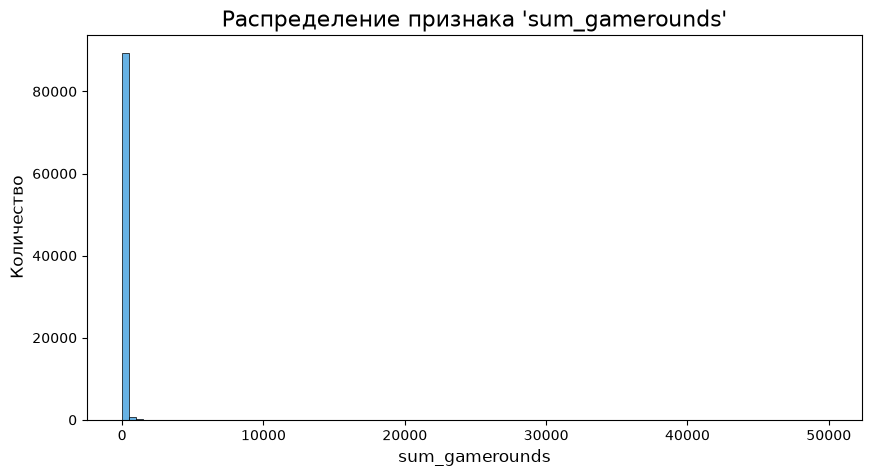

In [8]:
sns_plot(df, 'sum_gamerounds', bins = 100)

Text(0, 0.5, 'Число игроков')

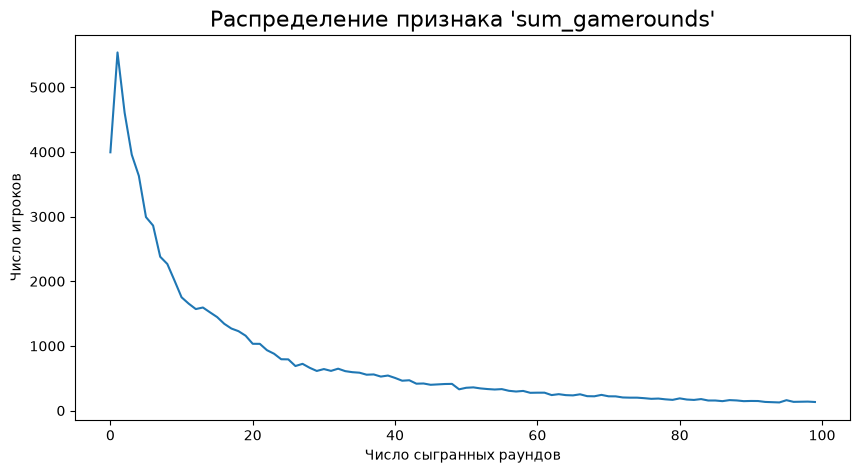

In [9]:
plot_df = df.groupby('sum_gamerounds')['userid'].count()
plt.figure(figsize=(10, 5))
plt.title("Распределение признака 'sum_gamerounds'", fontsize=16)
ax = plot_df.head(100).plot()
ax.set_xlabel('Число сыгранных раундов')
ax.set_ylabel('Число игроков')

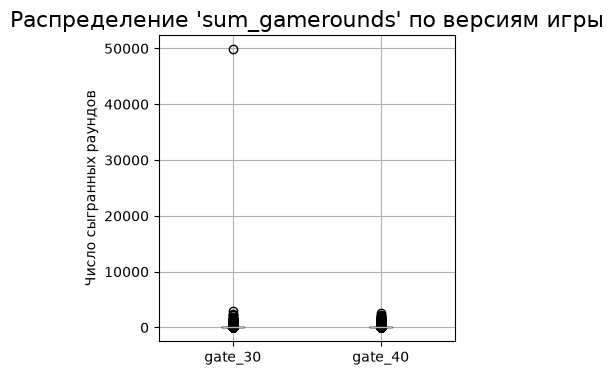

In [10]:
ax = df.boxplot(by='version', column='sum_gamerounds', figsize=(4, 4))
ax.set_xlabel('')
ax.set_ylabel('Число сыгранных раундов')
plt.title("Распределение 'sum_gamerounds' по версиям игры", fontsize=16)
plt.suptitle('')
plt.tight_layout()
plt.show()

**Выводы**  
Очень большие выбросы. Скорее всего есть экстремальные выбросы.

In [11]:
df_sorted = df.sort_values(by = 'sum_gamerounds', ascending=False)
df_sorted.head()

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True
7912,871500,gate_30,2961,True,True
29417,3271615,gate_40,2640,True,False
43671,4832608,gate_30,2438,True,True
48188,5346171,gate_40,2294,True,True


**Выводы**  
Много значений около 0, скорее всего не дошли до `gate_30`.  
Есть один экстремальный выброс = 49854. Похоже, что кто-то накрутил уровни с помощью бота.

Стоит удалить экстремальный выброс, тк он является техническим сбоем и вдальнейшем будет искажать метрики.

#### Бинарные признаки
- `version` - указывает, был ли игрок отнесен к контрольной группе (gate_30 - ворота 30-го уровня) или к тестовой группе (gate_40 - ворота 40-го уровня)    
- `retention_1` - бинарная переменная, указывающая, вернулся ли игрок к игре через один день после установки  
- `retention_7` - бинарная переменная, указывающая, вернулся ли игрок к игре через семь дней после установки 

count       90189
unique          2
top       gate_40
freq        45489
Name: version, dtype: object

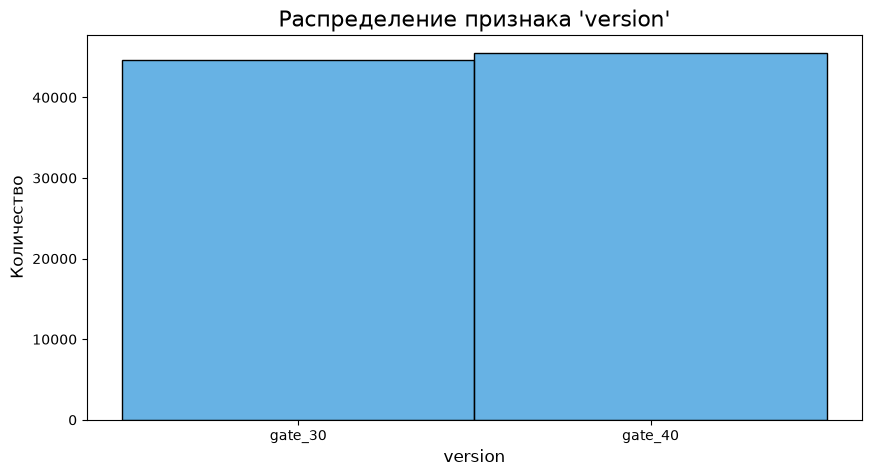

In [12]:
sns_plot(df, 'version', bins = 2)

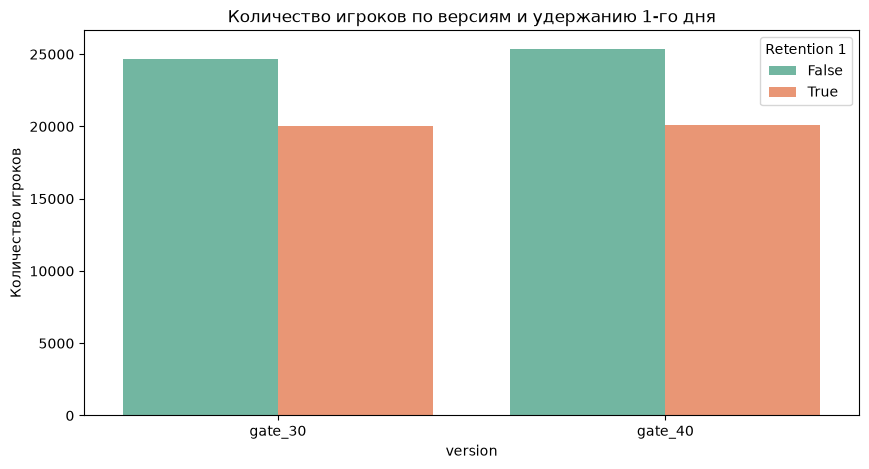

In [13]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="version", hue="retention_1", palette="Set2")
plt.title("Количество игроков по версиям и удержанию 1-го дня")
plt.ylabel("Количество игроков")
plt.legend(title="Retention 1")
plt.show()

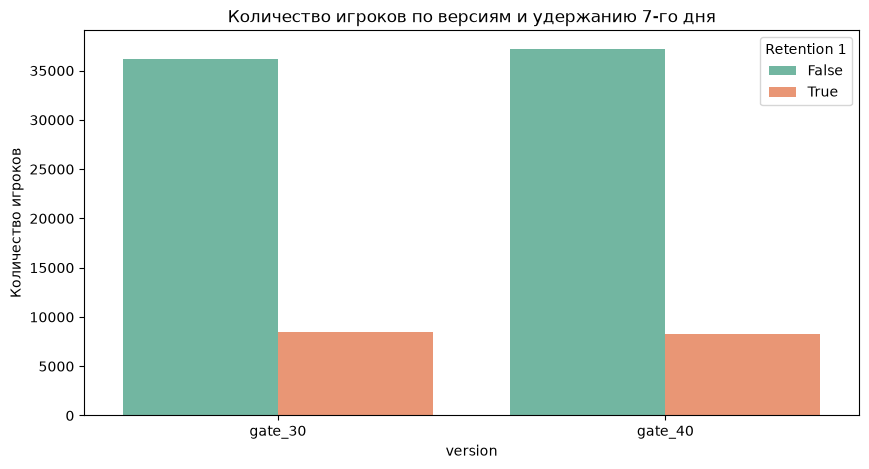

In [14]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="version", hue="retention_7", palette="Set2")
plt.title("Количество игроков по версиям и удержанию 7-го дня")
plt.ylabel("Количество игроков")
plt.legend(title="Retention 1")
plt.show()

**Выводы**  
Выборки сделаны равномерно.  
Видно, что Retenrion на 7 день резко меньше, чем Retention на 1.

### Нормализация данных
Удалим строки, у которых `sum_gamerounds` < 30 и экстремальный выброс `49854`.

Так же в данных есть игрок, который прошёл очень большое количество уровней 49854. Это аномальное значене, которое тоже следует обработать.

In [15]:
df_f = df[(df['sum_gamerounds'] > 30) & (df['sum_gamerounds'] != 49854)].reset_index(drop=True)

In [16]:
df_f_sorted = df_f.sort_values(by = 'sum_gamerounds', ascending = False)
df_f_sorted.head()

,userid,version,sum_gamerounds,retention_1,retention_7
2788,871500,gate_30,2961,True,True
10641,3271615,gate_40,2640,True,False
15816,4832608,gate_30,2438,True,True
17452,5346171,gate_40,2294,True,True
16813,5133952,gate_30,2251,True,True


In [17]:
df_f.describe()

,userid,sum_gamerounds
count,3.262600e+04,32626.00000
mean,5.001005e+06,125.11356
std,2.877988e+06,143.16099
min,3.370000e+02,31.00000
25%,2.522895e+06,46.00000
50%,4.983626e+06,75.00000
75%,7.487397e+06,146.00000
max,9.999768e+06,2961.00000


In [18]:
df_f.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,337,gate_30,38,True,False
1,377,gate_40,165,True,False
2,488,gate_40,179,True,True
3,540,gate_40,187,True,True
4,1574,gate_40,108,True,True


In [19]:
df_f.info()

<class 'pandas.DataFrame'>
RangeIndex: 32626 entries, 0 to 32625
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   userid          32626 non-null  int64
 1   version         32626 non-null  str  
 2   sum_gamerounds  32626 non-null  int64
 3   retention_1     32626 non-null  bool 
 4   retention_7     32626 non-null  bool 
dtypes: bool(2), int64(2), str(1)
memory usage: 828.5 KB


**Выводы**  
После удаления экстремального выброса `49854` и всех строк, где `sum_gamerounds` < 30, количество строк стало 32_626.  
Убрали 27_512 строк. Это очень много.

Скорее всего **сплитование пользователей на группы происходило неправильно**. Разделили всех польователей на группы вне зависимости дошли они до 30 уровня или нет. Из-за неправильного сплитования **выборка существенно сократилась**.

Надо было сплитовать пользователей в момент попадания на 30 уровень.

### Анализ нормализованных данных

#### Числовые признаки (int)
- `sum_gamerounds` - количество игровых раундов, сыгранных игроком в течение первой недели после установки

count    32626.00000
mean       125.11356
std        143.16099
min         31.00000
25%         46.00000
50%         75.00000
75%        146.00000
max       2961.00000
Name: sum_gamerounds, dtype: float64

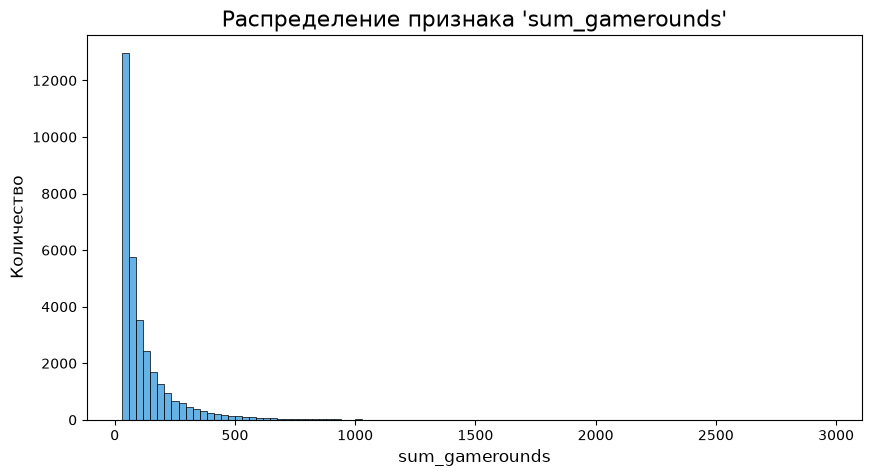

In [20]:
sns_plot(df_f, 'sum_gamerounds', bins = 100)

Text(0, 0.5, 'Число игроков')

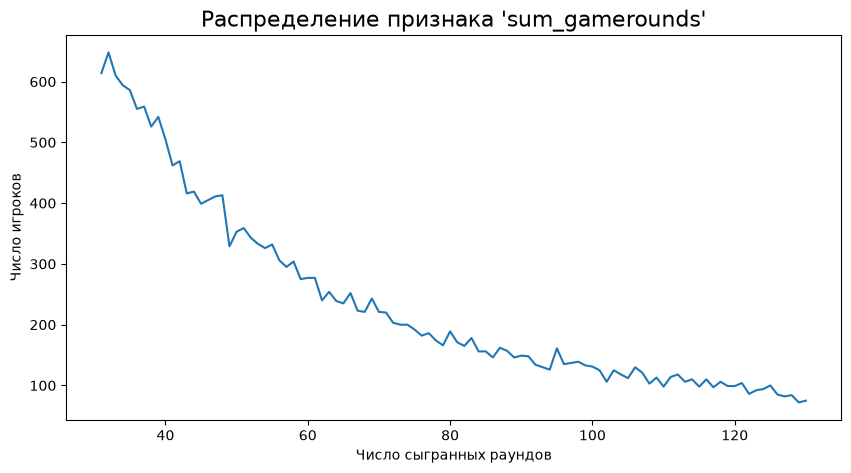

In [21]:
plot_df_f = df_f.groupby('sum_gamerounds')['userid'].count()
plt.figure(figsize=(10, 5))
plt.title("Распределение признака 'sum_gamerounds'", fontsize=16)
ax = plot_df_f.head(100).plot()
ax.set_xlabel('Число сыгранных раундов')
ax.set_ylabel('Число игроков')

Text(0, 0.5, 'Число сыгранных раундов')

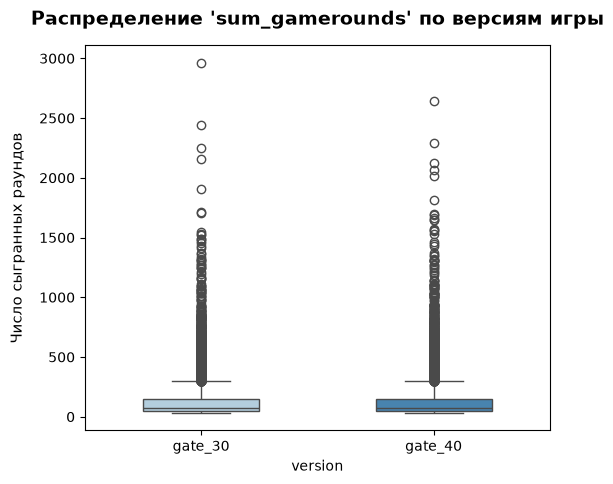

In [22]:
plt.figure(figsize=(6, 5))
ax = sns.boxplot(
    data=df_f, 
    x='version', 
    y='sum_gamerounds', 
    hue='version',       
    legend=False,       
    palette='Blues',    
    width=0.5,
)

plt.title("Распределение 'sum_gamerounds' по версиям игры", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Число сыгранных раундов", fontsize=11, labelpad=10)

In [23]:
df_f_sorted = df_f.sort_values(by = 'sum_gamerounds', ascending = False)
df_f_sorted.head(10)

,userid,version,sum_gamerounds,retention_1,retention_7
2788,871500,gate_30,2961,True,True
10641,3271615,gate_40,2640,True,False
15816,4832608,gate_30,2438,True,True
17452,5346171,gate_40,2294,True,True
16813,5133952,gate_30,2251,True,True
31497,9640085,gate_30,2156,True,True
13344,4090246,gate_40,2124,True,True
31969,9791599,gate_40,2063,True,True
2314,725080,gate_40,2015,True,True
217,69927,gate_30,1906,True,True


#### Бинарные признаки
- `version` - указывает, был ли игрок отнесен к контрольной группе (gate_30 - ворота 30-го уровня) или к тестовой группе (gate_40 - ворота 40-го уровня)    
- `retention_1` - бинарная переменная, указывающая, вернулся ли игрок к игре через один день после установки  
- `retention_7` - бинарная переменная, указывающая, вернулся ли игрок к игре через семь дней после установки 

count       32626
unique          2
top       gate_30
freq        16357
Name: version, dtype: object

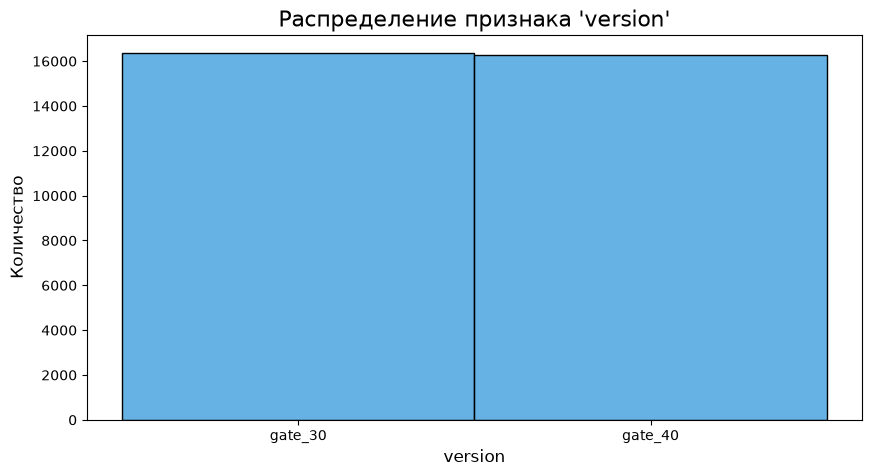

In [24]:
sns_plot(df_f, 'version', bins = 2)

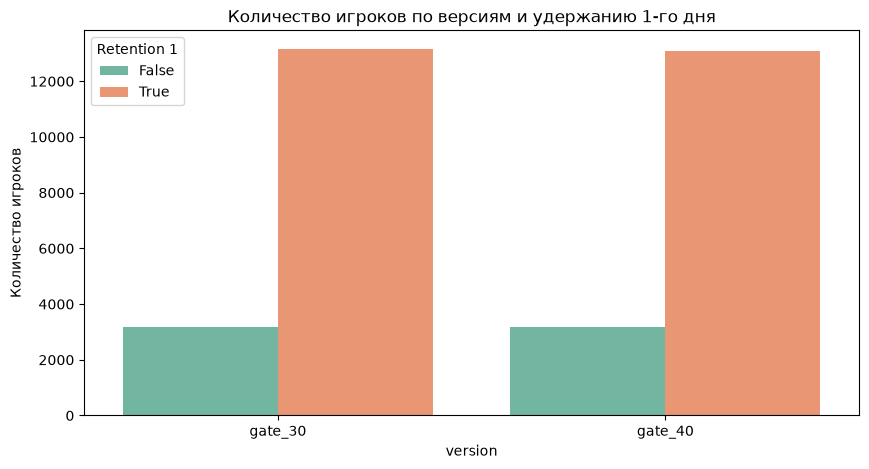

In [25]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_f, x="version", hue="retention_1", palette="Set2")
plt.title("Количество игроков по версиям и удержанию 1-го дня")
plt.ylabel("Количество игроков")
plt.legend(title="Retention 1")
plt.show()

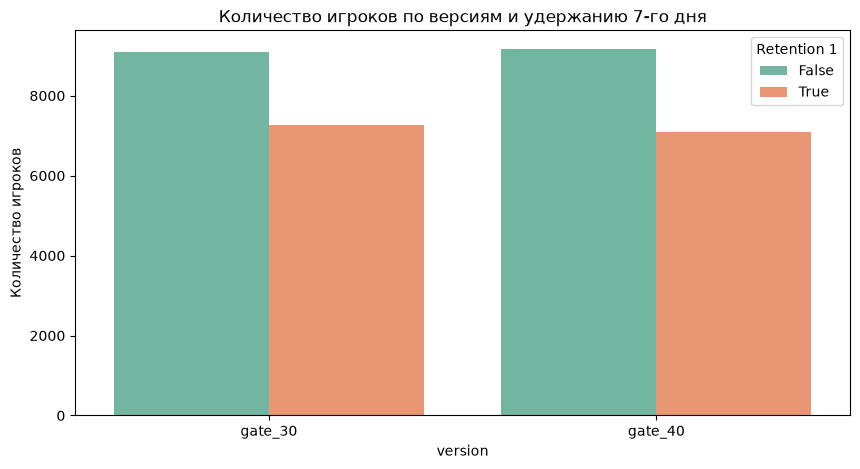

In [26]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_f, x="version", hue="retention_7", palette="Set2")
plt.title("Количество игроков по версиям и удержанию 7-го дня")
plt.ylabel("Количество игроков")
plt.legend(title="Retention 1")
plt.show()

## Выводы  
Убрала экстремальный выброс `49854` и все строки, где `sum_gamerounds` < 30.  
Теперь в выборке 32626 пользователей, которые дошли до момента изменения. Других пользователей, у которых `sum_gamerounds` < 30 нельзя учитывать в A/B - тесте, тк на их решение повлияло не изменение, а что-то другое.  
Выборки для `gate_30` и `gate_40` распределены равномерно.

Выбросы `sum_gamerounds`, оторажённые на ящике с усами оставляем, тк это природа данных. В мобильных бесплатных играх действует правило Парето: около 80% дохода компании генерируют всего 5-10% самых активных и преданных игроков (их называют «китами»).

Теперь по распределению Retention нельзя сделать однозначные выводы и следует провести A/B-тест.

In [27]:
# Создаём отдельный датафрейм с нормализованными данными для A/B-теста
df.to_csv(r'data/cookie_cats_norm.csv', index=False)

## A/B-тест
Retention - биномиальная фича.
Можно использовать 2 статистических критерия: z-тест пропорций и χ2.  
Тк у нас лишь две группы используем **одосторониий z-тест** пропорций.

**H0 гипотеза:** Удержание игроков (retention) не отличается между группами gate_30 и gate_40.  
**H1 гипотеза:** Удержание игроков (retention) в группе gate_40 больше, чем удержание игроков в группе gate_30. 
$$H_0: p_{40} = p_{30}$$
$$H_1: p_{40} > p_{30}$$

In [28]:
# Расчет удержания на 1-й день для каждой группы A/B
df_f.groupby('version')['retention_1'].sum() / df_f.groupby('version')['userid'].count()

version
gate_30    0.804793
gate_40    0.804905
dtype: float64

In [29]:
# Расчет удержания на 7-й день для обеих групп A/B
df_f.groupby('version')['retention_7'].sum() / df_f.groupby('version')['userid'].count()

version
gate_30    0.444152
gate_40    0.436290
dtype: float64

### Z-тест односторонний

**Считаем z-тест для Retention_1**  
Чтобы у нас посчиталсь альтернативная теория, что H_1: p_{40} > p_{30}, надо в функции proportions_ztest указать параметр alternative='smaller'. Тк из-за того, что данные хранятся в алфавитном поряядке, то первым аргументом будет gate_30, а не gate_40.

In [30]:
alpha = 0.05

df_agg = df_f.groupby('version')['retention_1'].agg(['sum', 'count', 'mean'])

n_obs = df_agg['count'].values # размеры выборок
m_obs = df_agg['sum'].values # число успехов

z_obs, p_val = proportions_ztest(m_obs, 
                                 n_obs, 
                                 value=0, 
                                 alternative='smaller'
                                )

print("Retention_1")
print(f'Наблюдаемое значение статистики:{z_obs:.3}')
print(f'p_value:{p_val:.3}')

Retention_1
Наблюдаемое значение статистики:-0.0255
p_value:0.49


**Вывод:**  
Так как полученное значение p_value = 0.49 для Retention_1 значительно больше установленного уровня значимости alpha = 0.05, мы **не отклоняем нулевую гипотезу H0**.

**Считаем z-тест для Retention_7**  

In [31]:
alpha = 0.05

df_agg = df_f.groupby('version')['retention_7'].agg(['sum', 'count', 'mean'])

n_obs = df_agg['count'].values # размеры выборок
m_obs = df_agg['sum'].values # число успехов

z_obs, p_val = proportions_ztest(m_obs, 
                                 n_obs, 
                                 value=0, 
                                 alternative='smaller'
                                )

print("Retention_7")
print(f'Наблюдаемое значение статистики:{z_obs:.3}')
print(f'p_value:{p_val:.3}')

Retention_7
Наблюдаемое значение статистики:1.43
p_value:0.924


**Вывод:**  
Так как полученное значение p_value = 0.924 для Retention_7 значительно больше установленного уровня значимости alpha = 0.05, мы **не отклоняем нулевую гипотезу H0**.

## Итоговые выводы
1) Была выявлена **ошибка сплитования** пользователей.
   Сплитование пользователей на группы происходило в момент установки игры, а не в момент достижения 30-го уровня (точка вмешательства). Из-за этого в выборку попали пользователи, которые никогда не доходили до ворот. После фильтрации выборка сократилась с 90_189 до 32_626 пользователей.
Корректный A/B-тест должен был проводиться с разделением пользователей на группы в момент достижения ими 30-го уровня, а не при установке игры.
2) Был обнаружен и **удалён экстремальный выброс** с 49_854 сыгранными раундами (вероятно, бот). Удалены пользователи с `sum_gamerounds < 30`, так как они не достигли точки вмешательства.
3) Был проведён A/B-тест и применён односторонний z-тест, результаты которого показали, что **сдвигать ворота на 40 уровень не нужно**. В обоих расчётах Retention альтернативная гипотеза (H1).